In [233]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import random
import pyslha
import tempfile
import gzip
import pylhe



pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disable copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams['figure.max_open_warning'] = 50
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']

colors = sns.color_palette('Paired')

# Functions to read the LHE and extract informations and distributions from it

In [30]:
def getLHEevents(fpath):
    """
    Reads a set of LHE files and returns a dictionary with the file labels as keys
    and the PyLHE Events object as values.
    """
    # Create temp file to handle syntax errors in LHE
    fd, fixedFile = tempfile.mkstemp(suffix='.lhe')
    os.close(fd)
    
    try:
        with gzip.open(fpath, 'rt') as f:
            # Optimize: Read and filter lines efficiently
            # Using list comprehension is slightly faster than appending in loop
            lines = [l for l in f if 'generate' not in l]
            
        with open(fixedFile, 'w') as newF:
            newF.writelines(lines)
            
        # Pylhe reads the file
        events = list(pylhe.read_lhe_with_attributes(fixedFile))
        nevents = pylhe.read_num_events(fixedFile)
        initBlock = pylhe.read_lhe_init(fixedFile)
        initBlock = initBlock['procInfo'][0]
    finally:
        if os.path.exists(fixedFile):
            os.remove(fixedFile)
            
    return nevents, events, initBlock

In [291]:
def getInfo(f,nlo = False,labelsDict=None):
    """
    Reads the banner and/or the summary of the process to extract information such: cross section, process name, model used, BSM masses and coupling.
    """
    if labelsDict is None:
        labelsDict = {'UV_BSM_ToyMode': 'VLF' , 'UV_BSM_ToyModel_NLO-UFO' : 'VLF', 'SMS-stop_NLO-UFO' : 'Scalar', 
                      'DMsimp_s_spin1': 'Z\'',
              'g g > t t~' : r'$g g \to t \bar{t}$', 'g g > t~ t' : r'$g g \to t \bar{t} $',
              'q q > t t~' : r'$q q \to t \bar{t}$', 'q q > t~ t' : r'$q q \to t \bar{t}$',
              'p p > t t~' : r'$p p \to t \bar{t}$', 'p p > t~ t' : r'$p p \to t \bar{t}$'
             }
    
    runDir = os.path.dirname(f)
    if not os.path.isdir(runDir):
        print(f'Folder {runDir} not found')
        return None
    banners = list(glob.glob(os.path.join(runDir,'*banner*txt')))
    if len(banners) != 1:
        print(f'{len(banners)} found (can only deal with 1 banner).')
        return None
    banner = banners[0]
    with open(banner,'r') as bannerF:
        bannerData = bannerF.read()
    
    # Get process and model from the banner or the proc card:
    if '<MGProcCard>' in bannerData:
        processData = bannerData.split('<MGProcCard>')[1].split('</MGProcCard>')[0]
        # Get model
        model_block = processData.split('Begin MODEL')[1].split('End   MODEL')[0]
        model_lines = [line.strip() for line in model_block.split('\n') if line.strip() and not line.strip().startswith('#')]
        model = model_lines[0] if model_lines else None
        # Get process
        proc_block = processData.split('Begin PROCESS')[1].split('End PROCESS')[0]
        proc_lines = [line.split('#')[0].strip() for line in proc_block.split('\n') if line.strip() and not line.strip().startswith('#')]
        proc = proc_lines[0] if proc_lines else None
        
    elif os.path.isfile(os.path.join(runDir,'../../Cards/proc_card_mg5.dat')):
        procCard = os.path.join(runDir,'../../Cards/proc_card_mg5.dat')
        with open(procCard,'r') as f:
            processData = f.read()
        processData = processData.replace('\\\n', '').replace('\\\r\n', '')
        processLines = processData.split('\n')
        modelLine = [l for l in processLines if 'import model' in l][-1]
        model = modelLine.strip().split(' ')[-1]
        model = os.path.basename(model)
        
        procLine = [l for l in processLines if 'generate' in l][-1]
        proc = procLine.strip().split('generate ')[-1]
    else:
        model = None
        proc = None

    if '[' in proc and ']' in proc:
        proc = proc.split('[')[0].strip()

    if proc in labelsDict:
        proc = labelsDict[proc]
    if model in labelsDict:
        model = labelsDict[model]

    # Get parameters data:
    parsData = bannerData.split('<slha>')[1].split('</slha>')[0]
    parsSLHA = pyslha.readSLHA(parsData)
    
    mT  = parsSLHA.blocks['MASS'][6]
    #Add the relevant parameters according to the model
    if 5000022 in parsSLHA.blocks['MASS'] and nlo == True:
        #VLF model
        mSDM = parsSLHA.blocks['MASS'][5000022]
        mPsiT = parsSLHA.blocks['MASS'][5000006]        
        yDM = list(parsSLHA.blocks['FRBLOCK'].values())[0]
        fileInfo = {'model' : model, 'process' : proc, 'mPsiT': mPsiT, 'mSDM': mSDM, 'yDM': yDM}
    elif 5000002 in parsSLHA.blocks['MASS']:
        #Scalar model
        mST = parsSLHA.blocks['MASS'][5000002]
        mChi = parsSLHA.blocks['MASS'][5000012]        
        yDM = list(parsSLHA.blocks['FRBLOCK'].values())[-1]
        mSDM = mChi
        mPsiT = mST
        fileInfo = {'model' : model, 'process' : proc, 'mST': mST, 'mChi': mChi, 'yDM': yDM}
    elif model == 'Z\'':
        #Z prime model
        mZ_prime = parsSLHA.blocks['MASS'][5000001]
        pars = list(parsSLHA.blocks['DMINPUTS'].values())
        gvd11 = pars[3]
        gvu11 = pars[4]
        gvd22 = pars[5]
        gvu22 = pars[6]
        gvd33 = pars[7]
        gvu33 = pars[8]
        #Adding decays and the width
        zp_decays = parsSLHA.decays[5000001]
        width_Zp = zp_decays.totalwidth
        
    
        br_dict = {}
        for channel in zp_decays.decays:
            pdg_str = "_".join(map(str, channel.ids))
            br_dict[f'BR_{pdg_str}'] = channel.br
            
        fileInfo = {'model' : model, 'process' : proc, 'mZp' : mZ_prime, 'wZp': width_Zp, 'gvd11': gvd11,
                        'gvu11': gvu11, 'gvd22': gvd22, 'gvu22': gvu22, 'gvd33': gvd33, 
                        'gvu33':gvu33}
        fileInfo['BRs'] = br_dict
    #Standar Model    
    else:
        fileInfo = {'model': 'SM'}

    # Get event data:
    if '<MGGenerationInfo>' in bannerData:
        eventData = bannerData.split('<MGGenerationInfo>')[1].split('</MGGenerationInfo>')[0]
        nEvents = eval(eventData.split('\n')[1].split(':')[1].strip())
        xsec = eval(eventData.split('\n')[2].split(':')[1].strip())
    elif os.path.isfile(os.path.join(runDir,'summary.txt')):
        with open(os.path.join(runDir,'summary.txt'),'r') as f:
            summaryLines = f.readlines()
        totalXsecLine = [l for l in summaryLines if 'Total cross section' in l][0]
        if 'DO NOT USE' in totalXsecLine:
            totalXsecLine = [i for i,l in enumerate(summaryLines) if 'Scale variation' in l][0]
            totalXsecLine = summaryLines[totalXsecLine+2]
        if 'Total cross section' in totalXsecLine:
            totalXsecLine = totalXsecLine.split(':')[1].strip()
        totalXsecLine = totalXsecLine.split(' +')[0].strip()
        totalXsecLine = totalXsecLine.replace('pb','')
        xsec = float(totalXsecLine)
        nEvents = -1
    else:
        nEvents = -1
        xsec = -1.0    

    #Save the crossection and number of events
    fileInfo['xsec (pb)'] = xsec
    fileInfo['nevents'] = nEvents

    
    return fileInfo

In [276]:
def getDistributions(filename, nlo = False, bias = False):
    """
    Function that reads the LHE file and extracts the distributions
    """
    nevents, events, initBlock = getLHEevents(filename)
    xSec = initBlock['xSection']
    xSecErr = initBlock['error']
    
    #Extract Raw Data into Arrays
    top_list = []
    atop_list = []
    w_list = []
    
    for ev in events:
        w = ev.eventinfo.weight
        w_list.append(w)
        
        p_t = None
        p_at = None
        
        for ptc in ev.particles:
            if ptc.id == 6:
                p_t = [ptc.px, ptc.py, ptc.pz, ptc.e]
            elif ptc.id == -6:
                p_at = [ptc.px, ptc.py, ptc.pz, ptc.e]
            # Handle case where user logic assumed only 2 particles of interest
            elif abs(ptc.id) == 6: 
                # Fallback if id is not exactly 6/-6 but logic implied it
                if p_t is None: p_t = [ptc.px, ptc.py, ptc.pz, ptc.e]
                else: p_at = [ptc.px, ptc.py, ptc.pz, ptc.e]

        #Ensure we found both
        if p_t and p_at:
            top_list.append(p_t)
            atop_list.append(p_at)
        else:
            w_list.pop() 

    # Convert to NumPy Arrays (Shape: N x 4)
    # P[:, 0]=px, P[:, 1]=py, P[:, 2]=pz, P[:, 3]=E
    P_t = np.array(top_list)
    P_at = np.array(atop_list)
    weights = np.array(w_list) / nevents

    if len(P_t) == 0:
        return {}

    # 2. Vectorized Calculations
    
    # Transverse Momentum (pT)
    # pT = sqrt(px^2 + py^2)
    pT_t = np.hypot(P_t[:, 0], P_t[:, 1])
    pT_at = np.hypot(P_at[:, 0], P_at[:, 1])
    
    # Total System (ttbar)
    P_tot = P_t + P_at
    
    # Invariant Mass (mTT)
    # m = sqrt(E^2 - p^2)
    p_tot_sq = np.sum(P_tot[:, 0:3]**2, axis=1)
    mTT = np.sqrt(P_tot[:, 3]**2 - p_tot_sq)
    
    # Rapidity
    rap_t = vectorized_rapidity(P_t)
    rap_tbar = vectorized_rapidity(P_at)
    rap_ttbar = vectorized_rapidity(P_tot)
    
    # Delta Phi
    deltaPhi = vectorized_delta_phi(P_t, P_at)
    
    # Center of Mass Velocity (Vectorized)
    # v_cm = p_tot_vec / E_tot
    # Shape (N, 3)
    # Use explicit newaxis for broadcasting division
    v_cm = P_tot[:, 0:3] / P_tot[:, 3][:, np.newaxis]
    
    # Cost (Cosine Theta in CM frame)
    # Boost tops to CM frame
    P_t_cm = vectorized_boost(P_t, v_cm)
    P_at_cm = vectorized_boost(P_at, v_cm)
    
    # Cos theta = pz / |p|
    p_t_cm_norm = np.linalg.norm(P_t_cm[:, 0:3], axis=1)
    cos_t = np.zeros_like(p_t_cm_norm)
    mask_nz = p_t_cm_norm > 0
    cos_t[mask_nz] = P_t_cm[mask_nz, 2] / p_t_cm_norm[mask_nz]
    
    p_at_cm_norm = np.linalg.norm(P_at_cm[:, 0:3], axis=1)
    cos_tbar = np.zeros_like(p_at_cm_norm)
    mask_nz_at = p_at_cm_norm > 0
    cos_tbar[mask_nz_at] = P_at_cm[mask_nz_at, 2] / p_at_cm_norm[mask_nz_at]

    # pT1, pT2 (Max/Min)
    pT1 = np.maximum(pT_t, pT_at)
    pT2 = np.minimum(pT_t, pT_at)

    dists = {
        'mTT': mTT, 
        'pT1': pT1, 
        'pT2': pT2, 
        'deltaPhi': deltaPhi, 
        'weights': weights, 
        'pT': pT_t, 
        'nevents': nevents, 
        'xsec (pb)': xSec, 
        'xSecErr (pb)': xSecErr, 
        'cost*': cos_t,
        'cost*_bar': cos_tbar, 
        'y_t': rap_t, 
        'y_tbar': rap_tbar,
        'abs_delta_y': np.abs(rap_t - rap_tbar), 
        'delta_y': np.abs(rap_t) - np.abs(rap_tbar)
    }

    info = getInfo(filename, nlo)
    #Reescale the crossection for NLO processes if bias was used
    distributions = crossSectionReescalling(dists, info, nlo, bias)

    return info | distributions

In [267]:
def crossSectionReescalling(distributions, info, nlo = False, bias = False):

    if nlo == True:
        distributions['weights'] = distributions['nevents']*distributions['weights']

    
    #Correcting the weights when doing bias generation
    if abs((distributions['xsec (pb)']-info['xsec (pb)'])/info['xsec (pb)']) > 0.01 and nlo == True:
        distributions['weights'] = (info['xsec (pb)']/distributions['xsec (pb)']) * distributions['weights']
        distributions['xsec (pb)'] = info['xsec (pb)']
    
    
    return distributions

In [268]:
def vectorized_rapidity(P):
    """
    Computes rapidity for an array of 4-vectors.
    P shape: (N, 4) [px, py, pz, E]
    """
    E = P[:, 3]
    pz = P[:, 2]
    diff = E - pz
    diff[diff == 0] = 1e-10 # Protect
    return 0.5 * np.log((E + pz) / diff)

In [269]:
def vectorized_delta_phi(P_a, P_b):
    """Computes delta phi between two arrays of 4-vectors."""
    # phi = arctan2(py, px)
    phi_a = np.arctan2(P_a[:, 1], P_a[:, 0])
    phi_b = np.arctan2(P_b[:, 1], P_b[:, 0])
    
    dphi = phi_a - phi_b
    

    dphi = (dphi + np.pi) % (2 * np.pi) - np.pi

    
   
    P_tot = P_a + P_b
    v_cm = P_tot[:, 0:3] / P_tot[:, 3][:, np.newaxis]
    
    P_a_cm = vectorized_boost(P_a, v_cm)
    P_b_cm = vectorized_boost(P_b, v_cm)
    
    phi_a_cm = np.arctan2(P_a_cm[:, 1], P_a_cm[:, 0])
    phi_b_cm = np.arctan2(P_b_cm[:, 1], P_b_cm[:, 0])
    
    dphi_cm = phi_a_cm - phi_b_cm
    dphi_cm = (dphi_cm + np.pi) % (2 * np.pi) - np.pi
    
    return dphi_cm


In [270]:
def vectorized_boost(p, v, c=1):
    """
    Vectorized Lorentz boost.
    p: (N, 4) [px, py, pz, E]
    v: (N, 3) [vx, vy, vz]
    """
    # Components
    px, py, pz, E = p[:, 0], p[:, 1], p[:, 2], p[:, 3]
    vx, vy, vz = v[:, 0], v[:, 1], v[:, 2]
    
    v2 = np.sum(v**2, axis=1)
    
    # Result array
    p_new = np.zeros_like(p)
    
    # Mask for v=0 case
    mask_nz = v2 > 0
    mask_z = ~mask_nz
    
    # If v=0, return p
    p_new[mask_z] = p[mask_z]
    
    # If v > 0, apply boost
    if np.any(mask_nz):
        _v2 = v2[mask_nz]
        _gamma = 1.0 / np.sqrt(1 - _v2)
        
        _px = px[mask_nz]
        _py = py[mask_nz]
        _pz = pz[mask_nz]
        _E  = E[mask_nz]
        _vx = vx[mask_nz]
        _vy = vy[mask_nz]
        _vz = vz[mask_nz]
        
        p_dot_v = _px*_vx + _py*_vy + _pz*_vz
        
        factor = (_gamma - 1) / _v2 * p_dot_v
        
        p_new[mask_nz, 3] = _gamma * (_E - p_dot_v) # E'
        
        term = factor - _gamma * _E
        p_new[mask_nz, 0] = _px + _vx * term
        p_new[mask_nz, 1] = _py + _vy * term
        p_new[mask_nz, 2] = _pz + _vz * term
        
    return p_new

# Extraction of the distributions and saving in an .npz file
If the .npz files already exists, it will skip it

## VLF Model

In [409]:
#Path to VLF events and the .npz outputs
events_VLF_dir = './processFolders/VLF/pp2ttbar/Events/'
output_VLF_dir = './processFolders/Distributions/VLF'

# Create the directory structure if it doesn't exist
os.makedirs(output_VLF_dir, exist_ok=True)

lhe_files = glob.glob(os.path.join(events_VLF_dir, '**', '*events.lhe*'), recursive=True)
print(f"Found {len(lhe_files)} LHE files to process.")

for lhe_file in lhe_files:
    run_dir = os.path.dirname(lhe_file)
    
    # Find the banner file in the exact same directory as the .lhe file
    banners = glob.glob(os.path.join(run_dir, '*banner.txt'))
    
    if not banners:
        print(f"[!] Warning: No banner found in {run_dir}. Skipping.")
        continue
        
    banner_name = os.path.basename(banners[0]) 
    
    try:
        # Strip the ending and split by underscores
        core_name = banner_name.replace('_banner.txt', '') 
        parts = core_name.split('_') 
        
        # Use negative indices to always grab the last three items, ignoring prefixes
        mPsiT = parts[-3]
        mSDM  = parts[-2]
        yDM   = parts[-1]
        
        # Construct the filename and output path
        out_filename = f"mPsiT_{mPsiT}_mSDM_{mSDM}_yDM_{yDM}.npz"
        out_file = os.path.join(output_VLF_dir, out_filename)
        
        #  Check: Skip the heavy calculation if the file exists!
        if os.path.exists(out_file):
            print(f"Skipping: {out_filename} already exists.")
            continue
            
        print(f"Processing: {out_filename} ...")
        
        # Only run the heavy extraction if we need to
        dists = getDistributions(lhe_file, True, True)
        
        if not dists:
            print(f"[!] Warning: No valid events found in {lhe_file}.")
            continue
            
        # Save the file
        np.savez(out_file, **dists)
        print(f"Successfully saved to {out_filename}.")
        
    except Exception as e:
        print(f"[X] Error processing {lhe_file} or parsing its banner {banner_name}: {e}")

print("Extraction complete!")

Found 1 LHE files to process.
Processing: mPsiT_1000_mSDM_900_yDM_6.npz ...
Successfully saved to mPsiT_1000_mSDM_900_yDM_6.npz.
Extraction complete!


## Scalar Model

In [474]:
#Path to VLF events and the .npz outputs
events_Scalar_dir = './processFolders/Scalar/pp2ttbar/Events/'
output_Scalar_dir = './processFolders/Distributions/Scalar'

# Create the directory structure if it doesn't exist
os.makedirs(output_Scalar_dir, exist_ok=True)

lhe_files = glob.glob(os.path.join(events_Scalar_dir, '**', '*events.lhe*'), recursive=True)
print(f"Found {len(lhe_files)} LHE files to process.")

for lhe_file in lhe_files:
    run_dir = os.path.dirname(lhe_file)
    
    # Find the banner file in the exact same directory as the .lhe file
    banners = glob.glob(os.path.join(run_dir, '*banner.txt'))
    
    if not banners:
        print(f"[!] Warning: No banner found in {run_dir}. Skipping.")
        continue
        
    banner_name = os.path.basename(banners[0]) 
    
    try:
        # Collect the the main parameters from the banner name
        core_name = banner_name.replace('_banner.txt', '') 
        parts = core_name.split('_') 
        mST = parts[-3]
        mChi  = parts[-2]
        yDM   = parts[-1]
        
        # Construct the filename and output path
        out_filename = f"mST_{mST}_mChi_{mChi}_yDM_{yDM}.npz"
        out_file = os.path.join(output_Scalar_dir, out_filename)
        
        #  Check if the .npz fiel already exists
        if os.path.exists(out_file):
            print(f"Skipping: {out_filename} already exists.")
            continue
            
        print(f"Processing: {out_filename} ...")
        
        # Only run the heavy extraction if we need to
        dists = getDistributions(lhe_file, True, True)
        
        if not dists:
            print(f"[!] Warning: No valid events found in {lhe_file}.")
            continue
            
        # Save the file
        np.savez(out_file, **dists)
        print(f"Successfully saved to {out_filename}.")
        
    except Exception as e:
        print(f"[X] Error processing {lhe_file} or parsing its banner {banner_name}: {e}")

print("Extraction complete!")

Found 1 LHE files to process.
Processing: mST_1000_mChi_900_yDM_10.npz ...
Successfully saved to mST_1000_mChi_900_yDM_10.npz.
Extraction complete!


## Z' model


In [465]:
#Path to VLF events and the .npz outputs
events_Z_dir = './processFolders/z_prime/pp2ttbar/Events/'
output_Z_dir = './processFolders/Distributions/z_prime'

# Create the directory structure if it doesn't exist
os.makedirs(output_Z_dir, exist_ok=True)

lhe_files = glob.glob(os.path.join(events_Z_dir, '**', '*events.lhe*'), recursive=True)
print(f"Found {len(lhe_files)} LHE files to process.")

for lhe_file in lhe_files:
    run_dir = os.path.dirname(lhe_file)
    
    # Find the banner file in the exact same directory as the .lhe file
    banners = glob.glob(os.path.join(run_dir, '*banner.txt'))
    
    if not banners:
        print(f"[!] Warning: No banner found in {run_dir}. Skipping.")
        continue
        
    banner_name = os.path.basename(banners[0]) 
    
    try:
        # Strip the ending and split by underscores
        core_name = banner_name.replace('_banner.txt', '') 
        parts = core_name.split('_') 
        
        # Use negative indices to always grab the last three items, ignoring prefixes
        mZp = parts[-2]
        widthZ  = parts[-1]
        
        # Construct the filename and output path
        out_filename = f"mZp_{mZp}_wZp_{widthZ}.npz"
        out_file = os.path.join(output_Z_dir, out_filename)
        
        #  Check: Skip the heavy calculation if the file exists!
        if os.path.exists(out_file):
            print(f"Skipping: {out_filename} already exists.")
            continue
            
        print(f"Processing: {out_filename} ...")
        
        # Only run the heavy extraction if we need to
        dists = getDistributions(lhe_file, False, True)
        
        if not dists:
            print(f"[!] Warning: No valid events found in {lhe_file}.")
            continue
            
        # Save the file
        np.savez(out_file, **dists)
        print(f"Successfully saved to {out_filename}.")
        
    except Exception as e:
        print(f"[X] Error processing {lhe_file} or parsing its banner {banner_name}: {e}")

print("Extraction complete!")

Found 1 LHE files to process.
Processing: mZp_2000_wZp_100.npz ...
Successfully saved to mZp_2000_wZp_100.npz.
Extraction complete!


# Loading the distributions from the .npz files for the desired parameters

## Standard model

In [456]:
# Define the values of the top partner mass, the DM mass and the yDM
target_mPsiT = 0
target_mSDM  = 0
target_yDM   = 0

# Get the filename from the parameters
base_dir = './processFolders/Distributions/sm'
filename = f"mPsiT_{target_mPsiT}_mSDM_{target_mSDM}_yDM_{target_yDM}.npz"
filepath = os.path.join(base_dir, filename)

# Load the data
if os.path.exists(filepath):
    print(f"[+] Loading {filename} ...")
    
    # Load the compressed arrays
    data = np.load(filepath, allow_pickle=True)
    
    # Convert the NpzFile object into a standard Python dictionary for easy access
    dists_sm = {key: data[key] for key in data.files}
    
    print(f"    [v] Successfully loaded {len(dists_sm.keys())} arrays.")
    print(f"    -> Events: {dists_VLF.get('nevents')} | Cross Section: {dists_sm.get('xsec (pb)')} pb")
    
else:
    print(f"[X] Error: The file {filename} was not found in {base_dir}.")

[+] Loading mPsiT_0_mSDM_0_yDM_0.npz ...
    [v] Successfully loaded 21 arrays.
    -> Events: 217193 | Cross Section: 461.02607 pb


## VLF model

In [475]:
# Define the values of the top partner mass, the DM mass and the yDM
target_mPsiT = 1000 #GeV
target_mSDM  = 900 #GeV
target_yDM   = 6 

# Get the filename from the parameters
base_dir = './processFolders/Distributions/VLF'
filename = f"mPsiT_{target_mPsiT}_mSDM_{target_mSDM}_yDM_{target_yDM}.npz"
filepath = os.path.join(base_dir, filename)

# Load the data
if os.path.exists(filepath):
    print(f"[+] Loading {filename} ...")
    
    # Load the compressed arrays
    data = np.load(filepath, allow_pickle=True)
    
    # Convert the NpzFile object into a standard Python dictionary for easy access
    dists_VLF = {key: data[key] for key in data.files}
    
    print(f"    [v] Successfully loaded {len(dists_VLF.keys())} arrays.")
    print(f"    -> Events: {dists_VLF.get('nevents')} | Cross Section: {dists_VLF.get('xsec (pb)')} pb")
    
else:
    print(f"[X] Error: The file {filename} was not found in {base_dir}.")


[+] Loading mPsiT_1000_mSDM_900_yDM_6.npz ...
    [v] Successfully loaded 20 arrays.
    -> Events: 217193 | Cross Section: 472.3 pb


## Scalar

In [476]:
# Define the values of the top partner mass, the DM mass and the yDM
target_mST = 1000 #GeV
target_mChi  = 900 #GeV
target_yDM   = 10

# Get the filename from the parameters
base_dir = './processFolders/Distributions/Scalar'
filename = f"mST_{target_mST}_mChi_{target_mChi}_yDM_{target_yDM}.npz"
filepath = os.path.join(base_dir, filename)

# Load the data
if os.path.exists(filepath):
    print(f"[+] Loading {filename} ...")
    
    # Load the compressed arrays
    data = np.load(filepath, allow_pickle=True)
    
    # Convert the NpzFile object into a standard Python dictionary for easy access
    dists_Scalar = {key: data[key] for key in data.files}
    
    print(f"    [v] Successfully loaded {len(dists_Scalar.keys())} arrays.")
    print(f"    -> Events: {dists_Scalar.get('nevents')} | Cross Section: {dists_Scalar.get('xsec (pb)')} pb")
    
else:
    print(f"[X] Error: The file {filename} was not found in {base_dir}.")

[+] Loading mST_1000_mChi_900_yDM_10.npz ...
    [v] Successfully loaded 20 arrays.
    -> Events: 726075 | Cross Section: 474.3 pb


## Z'

In [477]:
# Define the values of the top partner mass, the DM mass and the yDM
target_mZp = 2000 #GeV
target_wZp  = 100 #GeV 

# Get the filename from the parameters
base_dir = './processFolders/Distributions/z_prime'
filename = f"mZp_{target_mZp}_wZp_{target_wZp}.npz"
filepath = os.path.join(base_dir, filename)

# Load the data
if os.path.exists(filepath):
    print(f"[+] Loading {filename} ...")
    
    # Load the compressed arrays
    data = np.load(filepath, allow_pickle=True)
    
    # Convert the NpzFile object into a standard Python dictionary for easy access
    dists_Zp = {key: data[key] for key in data.files}
    
    print(f"    [v] Successfully loaded {len(dists_Zp.keys())} arrays.")
    print(f"    -> Events: {dists_Zp.get('nevents')} | Cross Section: {dists_Zp.get('xsec (pb)')} pb")
    
else:
    print(f"[X] Error: The file {filename} was not found in {base_dir}.")

[+] Loading mZp_2000_wZp_100.npz ...
    [v] Successfully loaded 26 arrays.
    -> Events: 500000 | Cross Section: 472.38832 pb


# Plotting the distributions

273.2215865557606
Scalar $p p \to t \bar{t}$
268.50082927616546
472.38832
Z' $p p \to t \bar{t}$
272.01176263572245


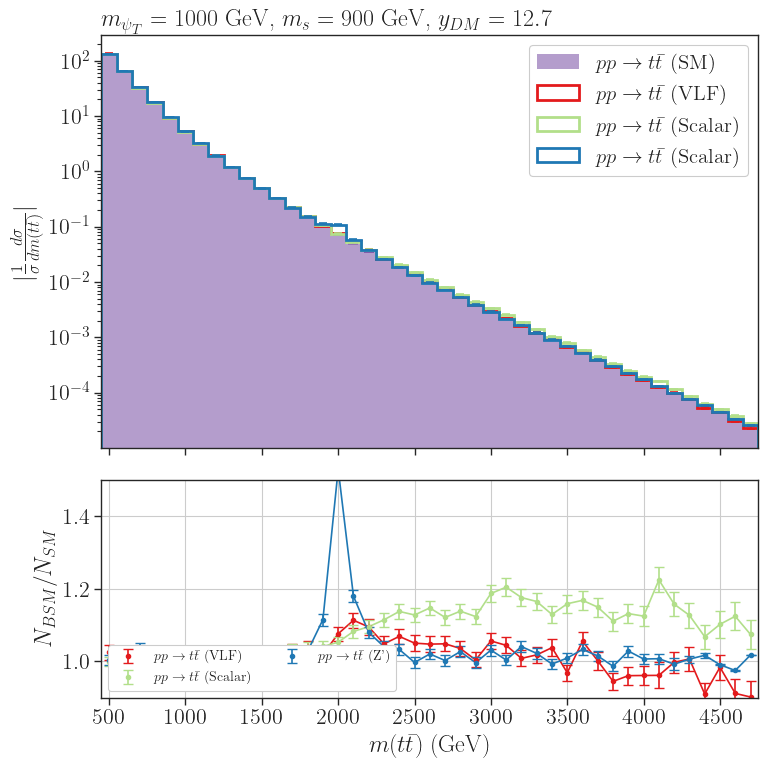

In [478]:
#Defining the space for the two plots 
fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
# -------------------------------------
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

#Defining the binning according to the BSM masses
bins = np.arange(450.,4800.,100.)

#SM plot arrays
labels_sm = []
pmodels = []
hists_sm = []
histsErr_sm = []


process = dists_sm['process']
model = dists_sm['model']
weights = dists_sm['weights']
pmodels.append(r'%s (%s)' %(process,model))
label = pmodels[-1]
labels_sm.append(label)
h,_ = np.histogram(dists_sm['mTT'],bins=bins,weights=dists_sm['weights'])
hists_sm.append(h)
#Compute MC error
hErr,_ = np.histogram(dists_sm['mTT'],bins=bins,weights=(np.array(dists_sm['weights']))**2)
hErr = np.sqrt(hErr)    
histsErr_sm.append(hErr)
#Plotting the SM hist
aux = axarr[0].hist(bins[:-1],weights=np.abs(h),label=r'$p p \to t\bar{t}$ (SM)',bins=bins,
                      color=sns.color_palette('Paired')[9],alpha=0.5,histtype='step',
                     linewidth=0,fill=True,stacked=True,linestyle='solid', zorder=0)

#hists_sm.append(sum(hists_sm))
#histsErr_sm.append(np.sqrt(histsErr_sm[0]**2 + histsErr_sm[1]**2))
#Plotting the SM error
x = (bins[:-1]+bins[1:])/2.0
y = aux[0]
#We have to propagate the error because we are using density = True
#yErr = abs(y)*np.sqrt((np.array(histsErr_sm[0])/np.array(hists_sm[0]))**2 + sum(np.power(histsErr_sm[0],2))/(sum(hists_sm[0])**2))  
yErr = histsErr_sm[0]
#Plot
axarr[0].errorbar(x,y, yerr = yErr,
               color=sns.color_palette('Paired')[9], fmt = 'none', ms = 5, capsize = 3.5, capthick = 1.2, 
                  ecolor =sns.color_palette('Paired')[9], barsabove = True, alpha = 0.5)


mPsiT = dists_VLF['mPsiT']
mSDM = dists_VLF['mSDM']
yDM = dists_VLF['yDM']

hists = []
histsErr = []
labels = []
model = dists_VLF['model']
process = dists_VLF['process']
model = dists_VLF['model']
weights = dists_VLF['weights']
pmodels.append(r'%s (%s)' %(process,model))
label = pmodels[-1]
labels.append(label)
weights = dists_VLF['weights']
h,_ = np.histogram(dists_VLF['mTT'],bins=bins, weights=dists_VLF['weights'])
hists.append(h)
print(sum(h))
#Compute MC error
hErr,_ = np.histogram(dists_VLF['mTT'],bins=bins,weights=(dists_VLF['weights'])**2)
hErr = np.sqrt(hErr)    
histsErr.append(hErr)
#Plotting the BSM hists
aux = axarr[0].hist(bins[:-1],weights=abs(h),label=labels[0],bins=bins, 
                  color=colors[5],alpha=1.0,histtype='step',
                 linewidth=2,fill=False,linestyle='solid')

#Plotting the errors
x = (bins[:-1]+bins[1:])/2.0
y = aux[0]
#Propagating the error since we are dealing with normalized histograms
#yErr = np.array(abs(y)*np.sqrt((np.array(hErr)/np.array(h))**2 + sum(np.array(hErr)**2)/(sum(h)**2)))
yErr = histsErr
axarr[0].errorbar(x,aux[0], yerr = yErr,
              color=colors[5], fmt = 'none', capsize = 3, capthick = 1.2, barsabove = True)

mST = dists_Scalar['mST']
mChi = dists_Scalar['mChi']
yDM = dists_Scalar['yDM']

process = dists_Scalar['process']
model = dists_Scalar['model']
weights = dists_Scalar['weights']
pmodels.append(r'%s (%s)' %(process,model))
label = pmodels[-1]
labels.append(label)
model = dists_Scalar['model']
print(model,dists_Scalar['process'])

weights = dists_Scalar['weights']
h,_ = np.histogram(dists_Scalar['mTT'],bins=bins, weights=dists_Scalar['weights'])
hists.append(h)
print(sum(h))
#Compute MC error
hErr,_ = np.histogram(dists_Scalar['mTT'],bins=bins,weights=(dists_Scalar['weights'])**2)
hErr = np.sqrt(hErr)    
histsErr.append(hErr)
#Plotting the BSM hists
aux = axarr[0].hist(bins[:-1],weights=abs(h),label=labels[1],bins=bins, 
                  color=colors[2],alpha=1.0,histtype='step',
                 linewidth=2,fill=False,linestyle='solid')

#Plotting the errors
x = (bins[:-1]+bins[1:])/2.0
y = aux[0]
#Propagating the error since we are dealing with normalized histograms
#yErr = np.array(abs(y)*np.sqrt((np.array(hErr)/np.array(h))**2 + sum(np.array(hErr)**2)/(sum(h)**2)))
yErr = hErr
axarr[0].errorbar(x,aux[0], yerr = yErr,
              color=colors[2], fmt = 'none', capsize = 3, capthick = 1.2, barsabove = True)
       



mZp = dists_Zp['mZp']
wZp = dists_Zp['wZp']
print(dists_Zp['xsec (pb)'])

process = dists_Zp['process']
model = dists_Zp['model']
weights = dists_Zp['weights']
pmodels.append(r'%s (%s)' %(process,model))
label = pmodels[-1]
labels.append(label)
model = dists_Zp['model']
print(model,dists_Zp['process'])
weights = dists_Zp['weights']
h,_ = np.histogram(dists_Zp['mTT'],bins=bins, weights=dists_Zp['weights'])
hists.append(h)
print(sum(h))
#Compute MC error
hErr,_ = np.histogram(dists_Zp['mTT'],bins=bins,weights=(dists_Zp['weights'])**2)
hErr = np.sqrt(hErr)    
histsErr.append(hErr)
#Plotting the BSM hists
aux = axarr[0].hist(bins[:-1],weights=abs(h),label=labels[1],bins=bins, 
                  color=colors[1],alpha=1.0,histtype='step',
                 linewidth=2,fill=False,linestyle='solid')

#Plotting the errors
x = (bins[:-1]+bins[1:])/2.0
y = aux[0]
#Propagating the error since we are dealing with normalized histograms
#yErr = np.array(abs(y)*np.sqrt((np.array(hErr)/np.array(h))**2 + sum(np.array(hErr)**2)/(sum(h)**2)))
yErr = hErr
axarr[0].errorbar(x,aux[0], yerr = yErr,
              color=colors[1], fmt = 'none', capsize = 3, capthick = 1.2, barsabove = True)


#Ratio plot

# --- NEW: Ratio calculation and plotting ---
x = (bins[:-1] + bins[1:]) / 2.0

# Calculate the ratio BSM / SM
ratio = np.divide(hists, hists_sm[0], out=np.ones_like(hists), where=hists_sm!=0)

# Propagate the errors for the ratio
# Using np.where to avoid division by zero
err_bsm_sq =  (np.array(histsErr)/np.array(hists))**2
err_sm_sq =  (np.array(histsErr_sm)/np.array(hists_sm))**2
ratio_err = np.abs(ratio) * np.sqrt(err_bsm_sq + err_sm_sq)
# Plot the ratio with its error on the bottom plot
c  = [colors[5], colors[2], colors[1]]
for k,r in enumerate(ratio):
    axarr[1].errorbar(x, r, yerr=ratio_err[k], color=c[k], fmt='o', ms=3, capsize=3.5, label = labels[k])
    axarr[1].plot(x, r, color=c[k]) # Add a line connecting points

# --- Main plot configs ---
#Main plot configs
axarr[0].legend(framealpha=1.0, ncol = 1, loc='upper right',fontsize=15)
axarr[0].set_title(r'$m_{\psi_T} = %1.0f$ GeV, $m_{s} = %1.0f$ GeV, $y_{DM} = %1.1f$' %(mPsiT,mSDM,yDM),
               loc='left')
axarr[0].set_yscale('log')
axarr[0].set_ylabel(r'$|\frac{1}{\sigma}\frac{d \sigma}{d m(t\bar{t})}|$')
axarr[0].set_xlim(bins.min(),bins.max())
#axarr[0].set_ylim(1e-8,1e-1)


# --- Ratio plot configs ---
#axarr[1].axhline(y=1, color='k', linestyle='--')
axarr[1].legend(framealpha=1.0,ncol = 2, loc='lower left',fontsize=10)
axarr[1].set_ylabel(r'$N_{BSM} / N_{SM}$')
axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)')
#axarr[1].set_yscale('symlog', linthresh = 0.001)
axarr[1].grid(True)
axarr[1].set_ylim(0.9, 1.5)
plt.tight_layout()
#filename = f"mtt_qq_mPsiT_{int(mPsiT)}_mSDM_{int(mSDM)}.png"
#plt.savefig(filename)
plt.show()

273.22151190670127
Scalar $p p \to t \bar{t}$
268.50074042509556
99.96757 472.38832
Z' $p p \to t \bar{t}$
272.01168199153096


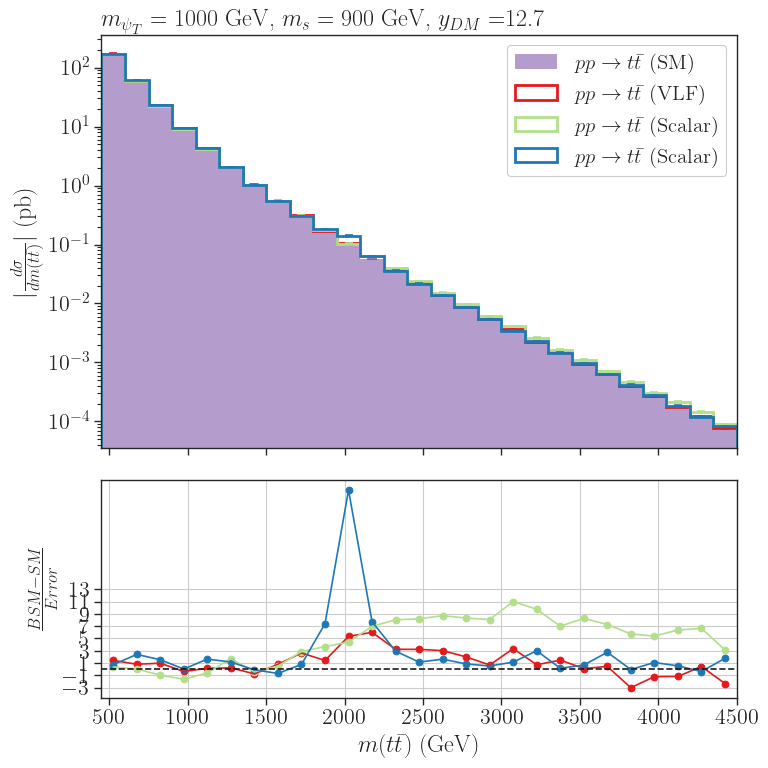

In [483]:
#Defining the space for the two plots 
fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
# -------------------------------------
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

#Defining the binning according to the BSM masses
bins = np.arange(450.,4600.,150.)

#SM plot arrays
labels_sm = []
pmodels = []
hists_sm = []
histsErr_sm = []


process = dists_sm['process']
model = dists_sm['model']
weights = dists_sm['weights']
pmodels.append(r'%s (%s)' %(process,model))
label = pmodels[-1]
labels_sm.append(label)
h,_ = np.histogram(dists_sm['mTT'],bins=bins,weights=dists_sm['weights'])
hists_sm.append(h)
#Compute MC error
hErr,_ = np.histogram(dists_sm['mTT'],bins=bins,weights=(np.array(dists_sm['weights']))**2)
hErr = np.sqrt(hErr)    
histsErr_sm.append(hErr)
#Plotting the SM hist
aux = axarr[0].hist(bins[:-1],weights=np.abs(h),label=r'$p p \to t\bar{t}$ (SM)',bins=bins,
                      color=sns.color_palette('Paired')[9],alpha=0.5,histtype='step',
                     linewidth=0,fill=True,stacked=True,linestyle='solid', zorder=0)

#hists_sm.append(sum(hists_sm))
#histsErr_sm.append(np.sqrt(histsErr_sm[0]**2 + histsErr_sm[1]**2))
#Plotting the SM error
x = (bins[:-1]+bins[1:])/2.0
y = aux[0]
#We have to propagate the error because we are using density = True
#yErr = abs(y)*np.sqrt((np.array(histsErr_sm[0])/np.array(hists_sm[0]))**2 + sum(np.power(histsErr_sm[0],2))/(sum(hists_sm[0])**2))  
yErr = histsErr_sm[0]
#Plot
axarr[0].errorbar(x,y, yerr = yErr,
               color=sns.color_palette('Paired')[9], fmt = 'none', ms = 5, capsize = 3.5, capthick = 1.2, 
                  ecolor =sns.color_palette('Paired')[9], barsabove = True, alpha = 0.5)


mPsiT = dists_VLF['mPsiT']
mSDM = dists_VLF['mSDM']
yDM = dists_VLF['yDM']

hists = []
histsErr = []
labels = []
model = dists_VLF['model']
process = dists_VLF['process']
model = dists_VLF['model']
weights = dists_VLF['weights']
pmodels.append(r'%s (%s)' %(process,model))
label = pmodels[-1]
labels.append(label)
weights = dists_VLF['weights']
h,_ = np.histogram(dists_VLF['mTT'],bins=bins, weights=dists_VLF['weights'])
hists.append(h)
print(sum(h))
#Compute MC error
hErr,_ = np.histogram(dists_VLF['mTT'],bins=bins,weights=(dists_VLF['weights'])**2)
hErr = np.sqrt(hErr)    
histsErr.append(hErr)
#Plotting the BSM hists
aux = axarr[0].hist(bins[:-1],weights=abs(h),label=labels[0],bins=bins, 
                  color=colors[5],alpha=1.0,histtype='step',
                 linewidth=2,fill=False,linestyle='solid')

#Plotting the errors
x = (bins[:-1]+bins[1:])/2.0
y = aux[0]
#Propagating the error since we are dealing with normalized histograms
#yErr = np.array(abs(y)*np.sqrt((np.array(hErr)/np.array(h))**2 + sum(np.array(hErr)**2)/(sum(h)**2)))
yErr = histsErr
axarr[0].errorbar(x,aux[0], yerr = yErr,
              color=colors[5], fmt = 'none', capsize = 3, capthick = 1.2, barsabove = True)

mST = dists_Scalar['mST']
mChi = dists_Scalar['mChi']
yDM = dists_Scalar['yDM']

process = dists_Scalar['process']
model = dists_Scalar['model']
weights = dists_Scalar['weights']
pmodels.append(r'%s (%s)' %(process,model))
label = pmodels[-1]
labels.append(label)
model = dists_Scalar['model']
print(model,dists_Scalar['process'])
weights = dists_Scalar['weights']
h,_ = np.histogram(dists_Scalar['mTT'],bins=bins, weights=dists_Scalar['weights'])
hists.append(h)
print(sum(h))
#Compute MC error
hErr,_ = np.histogram(dists_Scalar['mTT'],bins=bins,weights=(dists_Scalar['weights'])**2)
hErr = np.sqrt(hErr)    
histsErr.append(hErr)
#Plotting the BSM hists
aux = axarr[0].hist(bins[:-1],weights=abs(h),label=labels[1],bins=bins, 
                  color=colors[2],alpha=1.0,histtype='step',
                 linewidth=2,fill=False,linestyle='solid')

#Plotting the errors
x = (bins[:-1]+bins[1:])/2.0
y = aux[0]
#Propagating the error since we are dealing with normalized histograms
#yErr = np.array(abs(y)*np.sqrt((np.array(hErr)/np.array(h))**2 + sum(np.array(hErr)**2)/(sum(h)**2)))
yErr = hErr
axarr[0].errorbar(x,aux[0], yerr = yErr,
              color=colors[2], fmt = 'none', capsize = 3, capthick = 1.2, barsabove = True)
       

mZp = dists_Zp['mZp']
wZp = dists_Zp['wZp']
print(wZp, dists_Zp['xsec (pb)'])

process = dists_Zp['process']
model = dists_Zp['model']
weights = dists_Zp['weights']
pmodels.append(r'%s (%s)' %(process,model))
label = pmodels[-1]
labels.append(label)
model = dists_Zp['model']
print(model,dists_Zp['process'])
weights = dists_Zp['weights']
h,_ = np.histogram(dists_Zp['mTT'],bins=bins, weights=dists_Zp['weights'])
hists.append(h)
print(sum(h))
#Compute MC error
hErr,_ = np.histogram(dists_Zp['mTT'],bins=bins,weights=(dists_Zp['weights'])**2)
hErr = np.sqrt(hErr)    
histsErr.append(hErr)
#Plotting the BSM hists
aux = axarr[0].hist(bins[:-1],weights=abs(h),label=labels[1],bins=bins, 
                  color=colors[1],alpha=1.0,histtype='step',
                 linewidth=2,fill=False,linestyle='solid')

#Plotting the errors
x = (bins[:-1]+bins[1:])/2.0
y = aux[0]
#Propagating the error since we are dealing with normalized histograms
#yErr = np.array(abs(y)*np.sqrt((np.array(hErr)/np.array(h))**2 + sum(np.array(hErr)**2)/(sum(h)**2)))
yErr = hErr
axarr[0].errorbar(x,aux[0], yerr = yErr,
              color=colors[1], fmt = 'none', capsize = 3, capthick = 1.2, barsabove = True)







#axarr[0].set_ylim(1e-8,1e-1)
x = (bins[:-1] + bins[1:]) / 2.0

# Calculate the difference BSM - SM
# Using np.array to ensure element-wise subtraction
diff = np.array(hists) - np.array(hists_sm[0])

# Propagate the errors for the difference: sqrt(err_BSM^2 + err_SM^2)
diff_err = np.sqrt(np.array(histsErr)**2 + np.array(histsErr_sm[0])**2)

diff = diff/np.array(diff_err)

c = [colors[5], colors[2], colors[1]]
# Plot the difference with its error on the bottom plot
for k, d in enumerate(diff):
    #axarr[1].errorbar(x, d, yerr=diff_err[k], color='k', fmt='o', ms=3, capsize=3.5, label='VLF')
    axarr[1].scatter(x, d, color=c[k], label=labels[k])
    axarr[1].plot(x, d, color=c[k]) # Add a line connecting points

# --- Main plot configs ---
axarr[0].legend(framealpha=1.0, ncol=1, loc='upper right', fontsize=15)
axarr[0].set_title(r'$m_{\psi_T} = %1.0f$ GeV, $m_{s} = %1.0f$ GeV, $y_{DM} = $%1.1f' %(mPsiT,mSDM,yDM), loc='left')
axarr[0].set_yscale('log')
axarr[0].set_ylabel(r'$|\frac{d \sigma}{d m(t\bar{t})}|$ (pb)')
axarr[0].set_xlim(bins.min(), bins.max())
#axarr[0].set_ylim(1e-8,1e-1)

# --- Difference plot configs ---
axarr[1].axhline(y=0, color='k', linestyle='--') # Baseline is now at 0
#axarr[1].legend(framealpha=1.0, ncol=2, loc='lower left', fontsize=10)
axarr[1].set_ylabel(r'$\frac{BSM - SM}{Error}$') # Updated label
axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)')
axarr[1].grid(True)
axarr[1].set_yticks(np.arange(-3.0,15.0,2.0))

# I commented out the ylim since the difference will not be bound between 0.9 and 1.2
# Let matplotlib autoscale it first, then you can adjust if needed!
# axarr[1].set_ylim(-0.05, 0.05) 

plt.tight_layout()
#filename = f"mtt_qq_mPsiT_{int(mPsiT)}_mSDM_{int(mSDM)}.png"
#plt.savefig(filename)
plt.show()

In [480]:
print(np.sqrt(7.0**2 * (4.731e+02/4.745e+02)))

6.989665711964758


In [481]:

mTT_start = 1.5 * mPsiT
tail_mask = bins[:-1] >= mTT_start


tail_sum_NLO = np.sum(hists[0][tail_mask]) 
tail_sum_S   = np.sum( hists[1][tail_mask] )
tail_sum_Zp  = np.sum( hists[2][tail_mask]) 

yDM_S = np.sqrt(7.0**2 * tail_sum_NLO/tail_sum_S)
mu_Zp = np.sqrt(7.0**2 *tail_sum_NLO/tail_sum_Zp)
# Print the results
print(f"--- Sum for mTT >= {mTT_start} GeV ---")
print(f"VLF NLO:      {tail_sum_NLO:.5e}")
print(f"Scalar NLO:   {tail_sum_S:.5e}")
print(f"Z prime:      {tail_sum_Zp:.5e}")
print(f"yDM_S:      {yDM_S:.5e}")
print(f"mu_Z:      {mu_Zp:.5e}")
print()


--- Sum for mTT >= 1500.0 GeV ---
VLF NLO:      1.30675e+00
Scalar NLO:   1.31173e+00
Z prime:      1.33313e+00
yDM_S:      6.98669e+00
mu_Z:      6.93039e+00



In [482]:
mTT_start = 1.5 * mPsiT
tail_mask = bins[:-1] >= mTT_start


tail_sum_NLO = np.sum(hists[0][tail_mask]) - np.sum(hists_sm[0][tail_mask])
tail_sum_S   = np.sum( hists[1][tail_mask] )- np.sum(hists_sm[0][tail_mask])
tail_sum_Zp  = np.sum( hists[2][tail_mask]) - np.sum(hists_sm[0][tail_mask])

yDM_S = np.sqrt( tail_sum_NLO/tail_sum_S)
mu_Zp = np.sqrt(tail_sum_NLO/tail_sum_Zp)
# Print the results
print(f"--- Sum for mTT >= {mTT_start} GeV ---")
print(f"VLF NLO:      {tail_sum_NLO:.5e}")
print(f"Scalar NLO:   {tail_sum_S:.5e}")
print(f"Z prime:      {tail_sum_Zp:.5e}")
print(f"yDM_S:      {yDM_S:.5e}")
print(f"mu_Z:      {mu_Zp:.5e}")
print()

--- Sum for mTT >= 1500.0 GeV ---
VLF NLO:      3.90611e-02
Scalar NLO:   4.40428e-02
Z prime:      6.54422e-02
yDM_S:      9.41747e-01
mu_Z:      7.72579e-01

